LSTM model with 10 feature (Open, High, Low, Close, Volume, SMA_10, RSI_14, ATR_14, OBV) + Financial News Sentiment

Target: Future Close Price

Importing all the necessary Libraries 

In [1]:
#Standard library
import os
import random
from datetime import date,datetime, timedelta
import papermill as pm

#Data manipulation and numerical computing
import numpy as np
import pandas as pd
from scipy import stats

#Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Machine learning preprocessing and metrics
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

#TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, LSTM
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

#Technical Indicators 
import ta
from ta.trend import SMAIndicator
from ta.momentum import RSIIndicator
from ta.volatility import AverageTrueRange
from ta.volume import OnBalanceVolumeIndicator 

#Financial data
import yfinance as yf

#Common Function
import sys
sys.path.append("C:\\FYP\\sxk1332\\Next Day Predictions")
import Common_Functions
import importlib

Removing randomness from the model to enforce consistent results

In [2]:
#Ensures hash-based operations (like in dicts, sets, or some internal functions) are reproducible across runs
os.environ['PYTHONHASHSEED'] = '0'  # For hash-based operations

#Using the same seed ensures any ranom operations like weight initalization or dropout are the same each time
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

#Tensorflow operations can be non-deterministic even with a fixed seed. This code forced TensorFlow to use deterministic algorithms
tf.config.experimental.enable_op_determinism()

In [3]:
#Loading the sentiment CSV file before passing it to the LSTM
sentiment_df = pd.read_csv("C:\\FYP\sxk1332\\Next Day Predictions\\daily_apple_news_sentiment.csv")

#Converts the date column into a proper datetime object
sentiment_df["date"] = pd.to_datetime(sentiment_df["date"])

Function to fetch and download data (Apple Stock Price) from Yahoo everyday roughly for the past 10 years + Calculating techical indicators based on the correlation matrix:

In [4]:
ticker = 'AAPL'  
data = yf.download(ticker, start="2015-01-01")

#When you first download stock data using yf.download() the resulting dataframe uses date as the index (row labels)
#Here we are moving date from the index into a regular column - this allows you to extract the dates
data.reset_index(inplace=True)

# Flatten the column names if they're MultiIndex
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)


#Trend Indicator
sma10 = SMAIndicator(data['Close'], window=10).sma_indicator()
data['SMA_10'] = data['Close'] / sma10

#Momentum Indicator
data['RSI_14'] = RSIIndicator(data['Close'], window=14).rsi()

#Volatility Indicator
atr_val = AverageTrueRange(data['High'], data['Low'], data['Close'], window=14).average_true_range()
data['ATR_14'] = atr_val / data['Close']

obv_inst = OnBalanceVolumeIndicator(close=data['Close'], volume=data['Volume'])
data['OBV'] = obv_inst.on_balance_volume().diff() / data['Volume'].rolling(20).mean()

#data.to_csv("Before.csv", index=False)

#Merge sentiment with stock data using left join (add sentiment data where available)
data = data.merge(
    sentiment_df,
    left_on="Date",
    right_on="date",
    how="left"
)

#Add a new column to the original dataframe 
#Not all days have a sentiment value so add a 0 for all missing sentiment days
data["avg_sentiment"] = data["avg_sentiment"].fillna(0)

#The model cannot differentiate between 0 being a sentiment score and 0 being no news 
#so adding a binary column that gives the model context to only look at days with news

#A binary feature that tells the model whether news exists that day
data["has_news"] = (data["avg_sentiment"] != 0).astype(int)

data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.fillna(method='ffill', inplace=True) 
data.dropna(inplace=True)  

#data.to_csv("After.csv", index=False)

# Define feature 
price_features = ['Close', 'Open', 'High', 'Low', 'Volume', 'SMA_10', 'RSI_14', 'ATR_14', 'OBV']
sentiment_features = ['avg_sentiment', 'has_news']

#Extract specific columns from your DataFrame and converts them into a NumPy array.
price_data = data[price_features].values
sentiment_data = data[sentiment_features].values
datetime_index = data['Date'].values

[*********************100%***********************]  1 of 1 completed


C:\Users\Sxk1332\AppData\Local\Temp\ipykernel_41384\2880145636.py:48: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


In [5]:
# Get the number of close prices
print(f"Number of close prices: {len(data)}")

Number of close prices: 2827


Splitting the data into a training set (first 85%) and testing set (remaining 15%)

In [6]:
#Defining the split size
#70% of the total data to be used for training, 15% for validation, and 15% for testing
total_size = len(data)

train_size = int(len(data) * 0.70)
val_size = int(len(data) * 0.15)

#Chronogically splitting the data so first 70% is training, the next 15% is validation and the remaining 15% is testing
train_price = price_data[:train_size] #gets items from 0 to 69
val_price = price_data[train_size:train_size + val_size] #gets items from 69 to 84
test_price = price_data[train_size + val_size:] #gets items from 85 to 99

#Split Sentiment Data (no scaling done)
train_sent = sentiment_data[:train_size]
val_sent = sentiment_data[train_size:train_size + val_size]
test_sent = sentiment_data[train_size + val_size:]

print("Total samples:", total_size)

print("\nDataset sizes:")
print(f"Training set   : {len(train_price)} samples ({len(train_price)/total_size:.2%})")
print(f"Validation set : {len(val_price)} samples ({len(val_price)/total_size:.2%})")
print(f"Test set       : {len(test_price)} samples ({len(test_price)/total_size:.2%})")

print("Train:", train_price.shape)
print("Val  :", val_price.shape)
print("Test :", test_price.shape)

print("\nCheck sum:", len(train_price) + len(val_price) + len(test_price))

Total samples: 2827

Dataset sizes:
Training set   : 1978 samples (69.97%)
Validation set : 424 samples (15.00%)
Test set       : 425 samples (15.03%)
Train: (1978, 9)
Val  : (424, 9)
Test : (425, 9)

Check sum: 2827


Normalizing the price data using a Min-Max Scaler. Ensuring to only fit the scaler on the training data to prevent data leaks. 

In [7]:
#Calculating the number of features, and creating a seperate scaler for each feature
num_features = train_price.shape[1]
scalers = [MinMaxScaler(feature_range=(0, 1)) for _ in range(num_features)]

#Fit each scaler on only the training data for that specific column - this avoids data leaks
#Here we just calculate and store the min and max values for each feature
for i, scaler in enumerate(scalers):
    scaler.fit(train_price[:, [i]])

#Transform each column individually using its corresponding scaler
#Transforming means actually applying the MinMax formula to get new values between 0-1
#np.hstack then stacks the scaled columns back together horizontally
def scale_data(data, scalers):
    return np.hstack([scalers[i].transform(data[:, [i]]) for i in range(len(scalers))])

#All three datasets are transformed using the scalers fitted on the training data
train_price_scaled = scale_data(train_price, scalers)
val_price_scaled = scale_data(val_price, scalers)
test_price_scaled = scale_data(test_price, scalers)

print("Train scaled min/max:", train_price_scaled.min(), train_price_scaled.max())
print("Val   scaled min/max:", val_price_scaled.min(), val_price_scaled.max())
print("Test  scaled min/max:", test_price_scaled.min(), test_price_scaled.max())

Train scaled min/max: 0.0 1.0
Val   scaled min/max: -0.018166668377797478 1.3617132496970101
Test  scaled min/max: -0.3336528583304499 1.6957202529472608


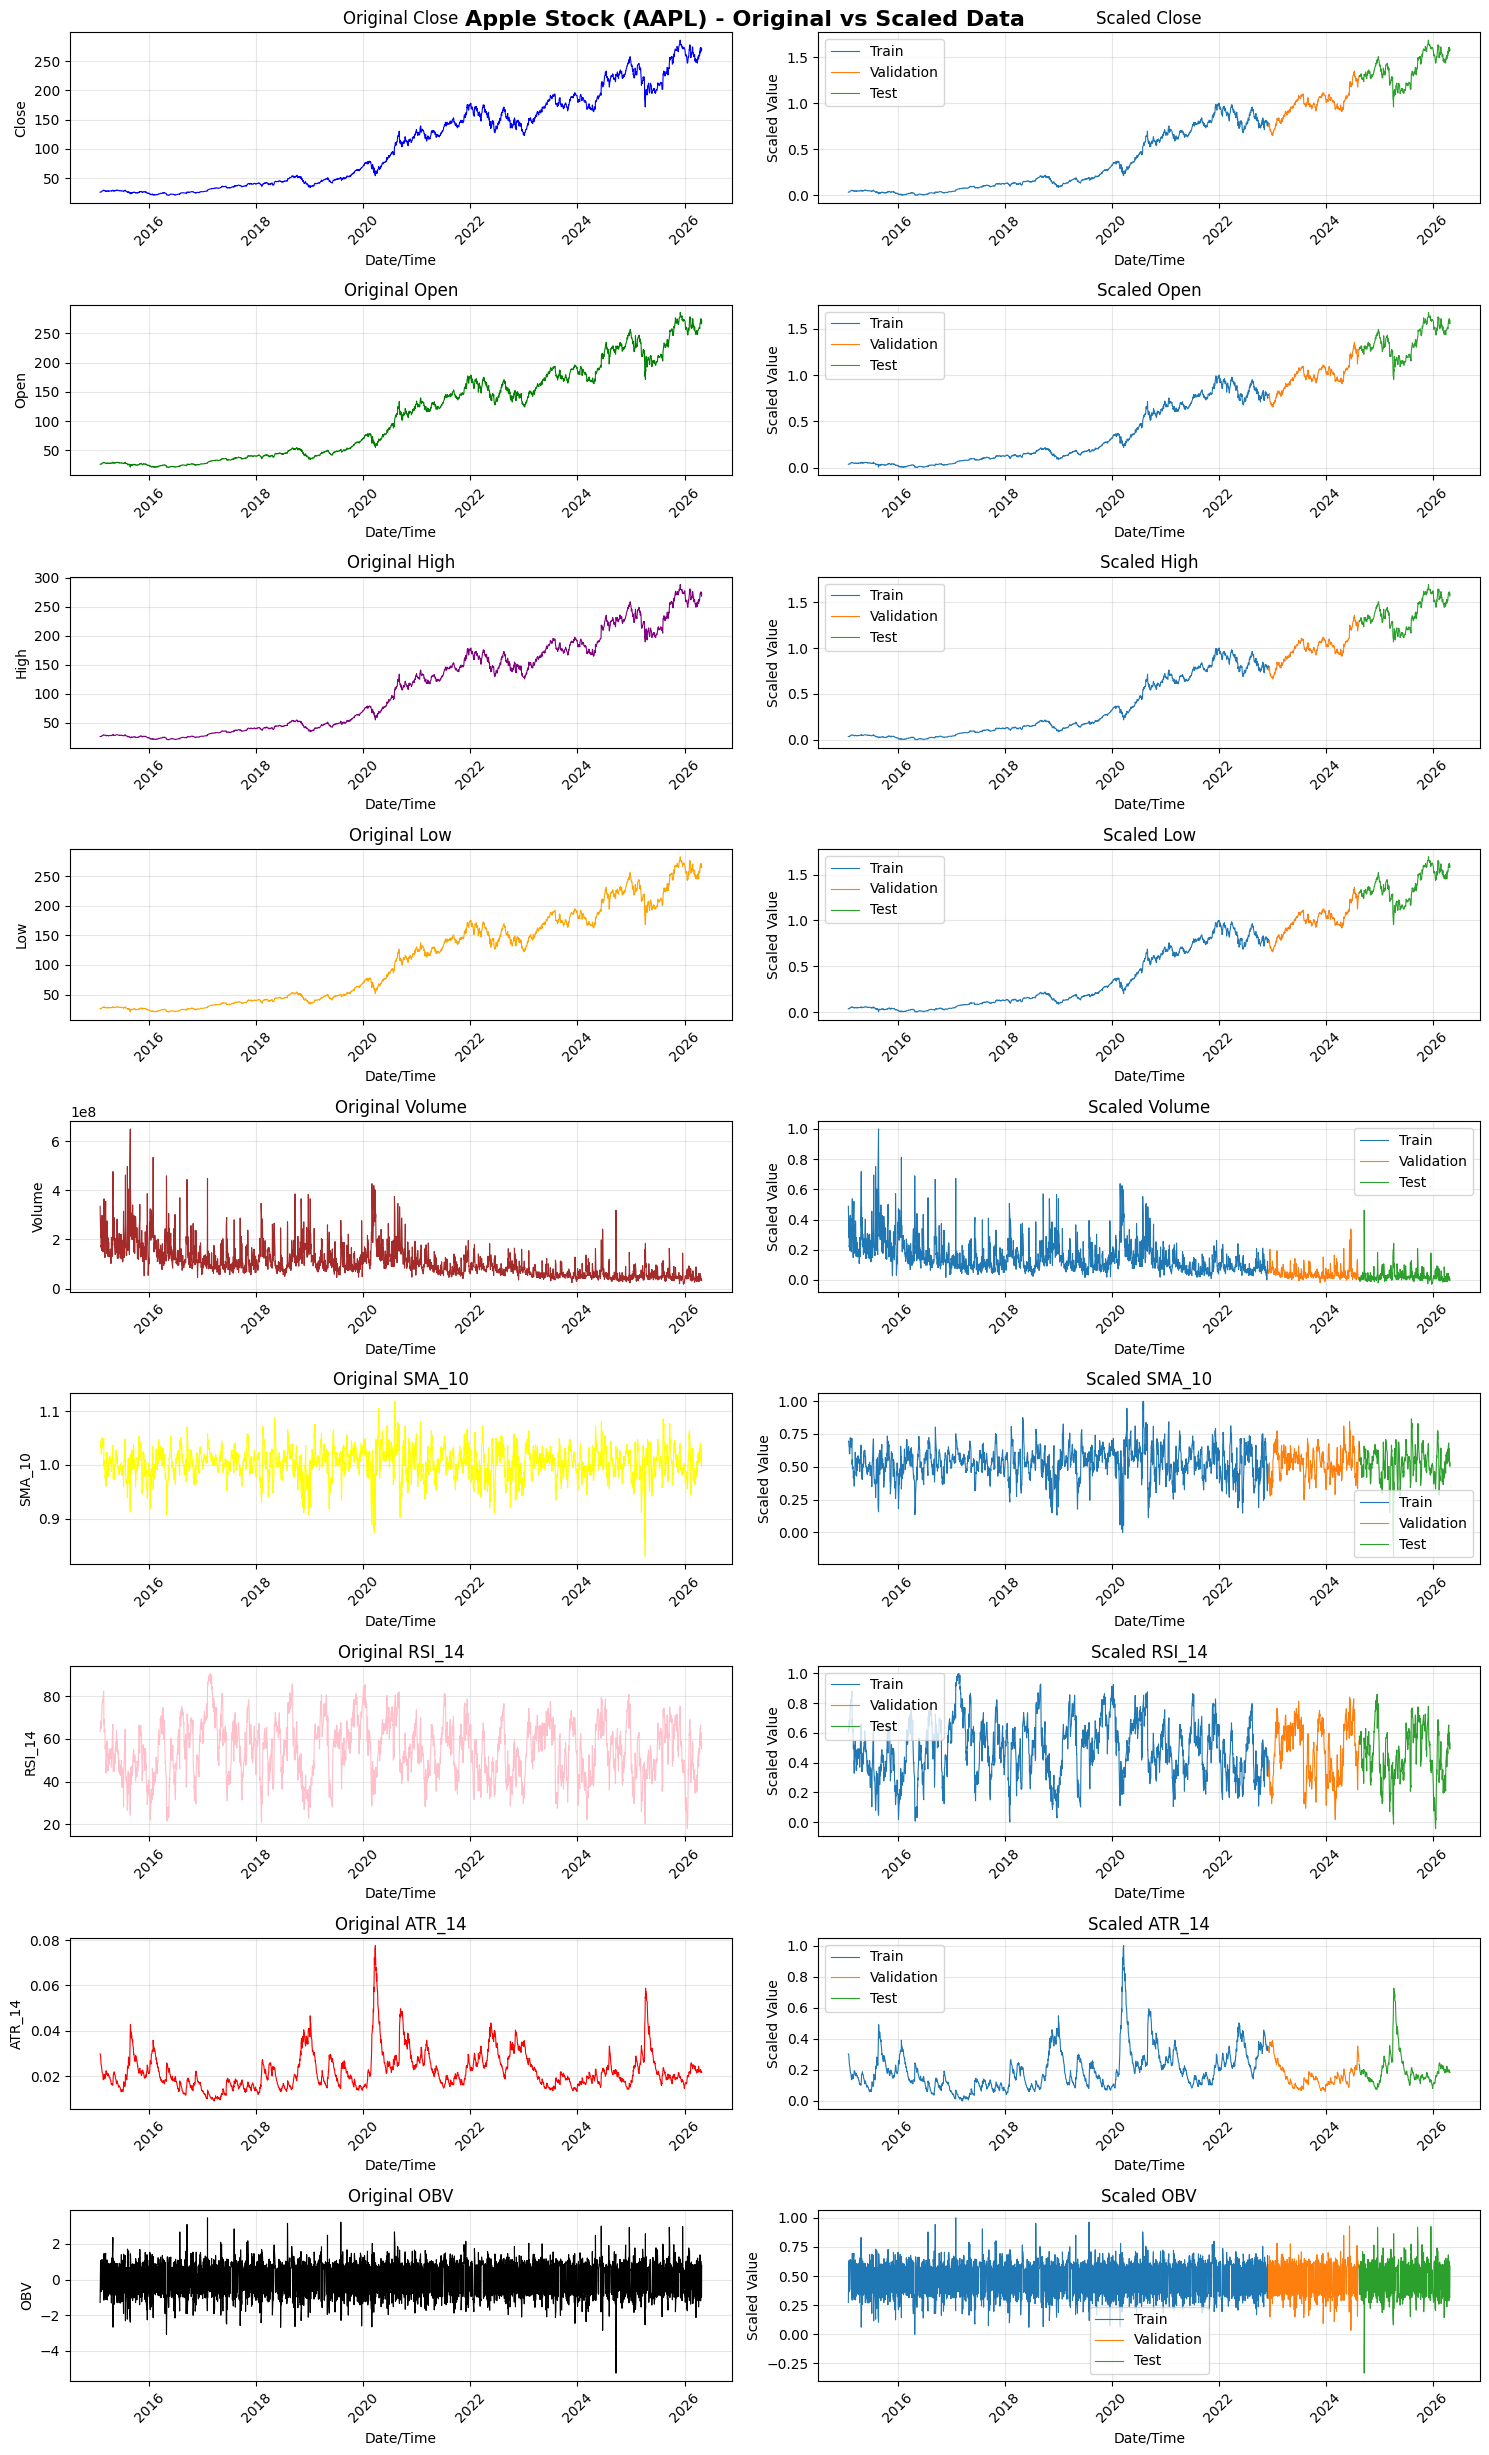

In [8]:
# Reconstructing datetime splits to match data splits
datetime_train = datetime_index[:train_size]
datetime_val   = datetime_index[train_size:train_size + val_size]
datetime_test  = datetime_index[train_size + val_size:]

num_features = train_price.shape[1]

# Create 8x2 subplot layout for both features
fig, axes = plt.subplots(num_features, 2, figsize=(15, 25))
fig.suptitle(
    'Apple Stock (AAPL) - Original vs Scaled Data',
    fontsize=16,
    fontweight='bold'
)

feature_titles = ['Close', 'Open', 'High', 'Low', 'Volume', 'SMA_10', 'RSI_14', 'ATR_14', 'OBV']
colors = ['blue', 'green', 'purple', 'orange', 'brown', 'yellow', 'pink', 'red', 'Black']

for i in range(num_features):
    # Original
    axes[i, 0].plot(datetime_index, price_data[:, i], color=colors[i], linewidth=0.8)
    axes[i, 0].set_title(f'Original {feature_titles[i]}')
    axes[i, 0].set_xlabel('Date/Time')
    axes[i, 0].set_ylabel(feature_titles[i])
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].tick_params(axis='x', rotation=45)

    # Scaled
    axes[i, 1].plot(datetime_train, train_price_scaled[:, i], label='Train', linewidth=0.8)
    axes[i, 1].plot(datetime_val, val_price_scaled[:, i], label='Validation', linewidth=0.8)
    axes[i, 1].plot(datetime_test, test_price_scaled[:, i], label='Test', linewidth=0.8)
    axes[i, 1].set_title(f'Scaled {feature_titles[i]}')
    axes[i, 1].set_xlabel('Date/Time')
    axes[i, 1].set_ylabel('Scaled Value')
    axes[i, 1].grid(True, alpha=0.3)
    axes[i, 1].tick_params(axis='x', rotation=45)
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

In [9]:
#Stack scaled prices with unscaled sentiment
train_final = np.hstack([train_price_scaled, train_sent])
val_final = np.hstack([val_price_scaled, val_sent])
test_final = np.hstack([test_price_scaled, test_sent])

all_cols = price_features + sentiment_features

datasets = {
    "Train": train_final,
    "Validation": val_final,
    "Test": test_final
}

#Loop through the dictionary items
for name, dataset_array in datasets.items():
    rows, cols = dataset_array.shape
    print(f"{name} Set - Rows: {rows}, Columns: {cols}")

Train Set - Rows: 1978, Columns: 11
Validation Set - Rows: 424, Columns: 11
Test Set - Rows: 425, Columns: 11


Creating a Sliding Window to prepare the input data for the LSTM model

In [10]:
def create_multifeature_dataset_with_context(data, time_step, context_data = None):

    if context_data is not None:
        data = np.vstack([context_data[-time_step:], data])

    X, y = [] ,[]

    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step, :])  #here we grab all columns and rows per timesteps (rows 0-24 first time)
        y.append(data[i + time_step, 0])  #here we only predict the Close price (row 25)

    #Convert the lists to NumPy arrays for compatibility with neural network frameworks
    return np.array(X), np.array(y)

time_step = 25

X_train, y_train = create_multifeature_dataset_with_context(train_final, time_step)
X_val, y_val     = create_multifeature_dataset_with_context(val_final, time_step, context_data=train_final)
X_test, y_test   = create_multifeature_dataset_with_context(test_final, time_step, context_data=val_final)

# Check shapes
print("Shapes of LSTM datasets:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape}, y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}, y_test : {y_test.shape}")


Shapes of LSTM datasets:
X_train: (1953, 25, 11), y_train: (1953,)
X_val  : (424, 25, 11), y_val  : (424,)
X_test : (425, 25, 11), y_test : (425,)


Building and Training the model

In [11]:
model = Sequential()

model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
model.add((LSTM(units=96, return_sequences=False, kernel_regularizer=l2(0.001))))
model.add(Dropout(0.15))

model.add(Dense(units=1))

#compile the model
model.compile(optimizer=Adam(learning_rate=5e-3), loss='mean_squared_error', metrics=['MAE'])

#Train the model
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,          
    patience=5,               
    verbose=1           
)

callbacks = [early_stop, reduce_lr]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val), 
    epochs=150,
    batch_size=96,
    shuffle=False,
    callbacks=callbacks,
    verbose=2
)

test_loss, test_mae = model.evaluate(X_test, y_test)
print("Test MAE:", test_mae)

Epoch 1/150


21/21 - 2s - 117ms/step - MAE: 0.0938 - loss: 0.0275 - val_MAE: 0.1866 - val_loss: 0.0465 - learning_rate: 0.0050


Epoch 2/150


21/21 - 1s - 47ms/step - MAE: 0.0999 - loss: 0.0198 - val_MAE: 0.1677 - val_loss: 0.0377 - learning_rate: 0.0050


Epoch 3/150


...

21/21 - 1s - 30ms/step - MAE: 0.0180 - loss: 0.0021 - val_MAE: 0.0181 - val_loss: 0.0018 - learning_rate: 8.0000e-06


 1/14 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - MAE: 0.0187 - loss: 0.0019

 8/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - MAE: 0.0235 - loss: 0.0024 

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - MAE: 0.0272 - loss: 0.0026


Test MAE: 0.02720729075372219


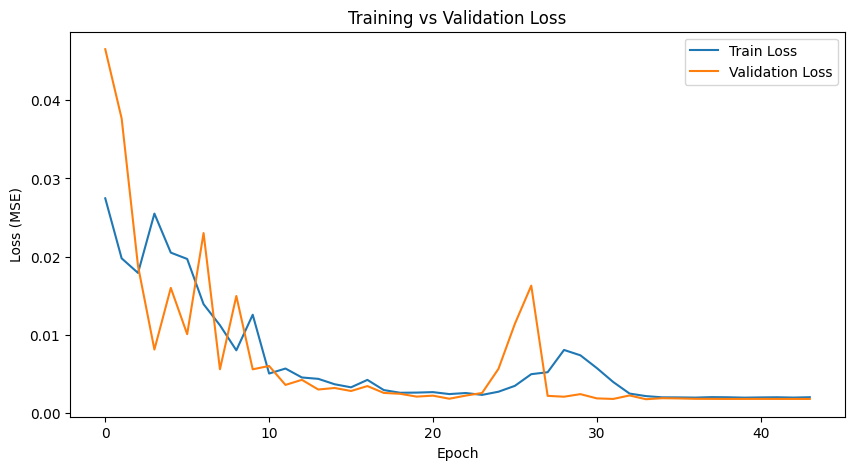

In [12]:
# Plot Loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

Predictions

In [13]:
#This gets the predictions from the model - but these are scaled from (0-1 range) beacuse the model was trained on scaled data
predictions_scaled = model.predict(X_test)

#Inverse transform reverses the scaling applied earlier and converts predictions from 0-1 range back to actual dollar values
predictions = scalers[0].inverse_transform(predictions_scaled)
y_test_unscaled = scalers[0].inverse_transform(y_test.reshape(-1, 1))

#Flatten the 2D array back to 1D arrays which is easier for metrics calculations
predictions = predictions.flatten()
y_test_unscaled = y_test_unscaled.flatten()

#Calculate metrics on unscaled data
#RMSE (Root Mean Squared Error): Average prediction error, penalizes large errors more
rmse = np.sqrt(mean_squared_error(y_test_unscaled, predictions))

#MAE (Mean Absolute Error): Average absolute difference between predicted and actual prices
mae = mean_absolute_error(y_test_unscaled, predictions)

print(f"\nUnscaled Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Unscaled Mean Absolute Error (MAE): ${mae:.2f}")


 1/14 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step

10/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step



Unscaled Root Mean Squared Error (RMSE): $5.76
Unscaled Mean Absolute Error (MAE): $4.29


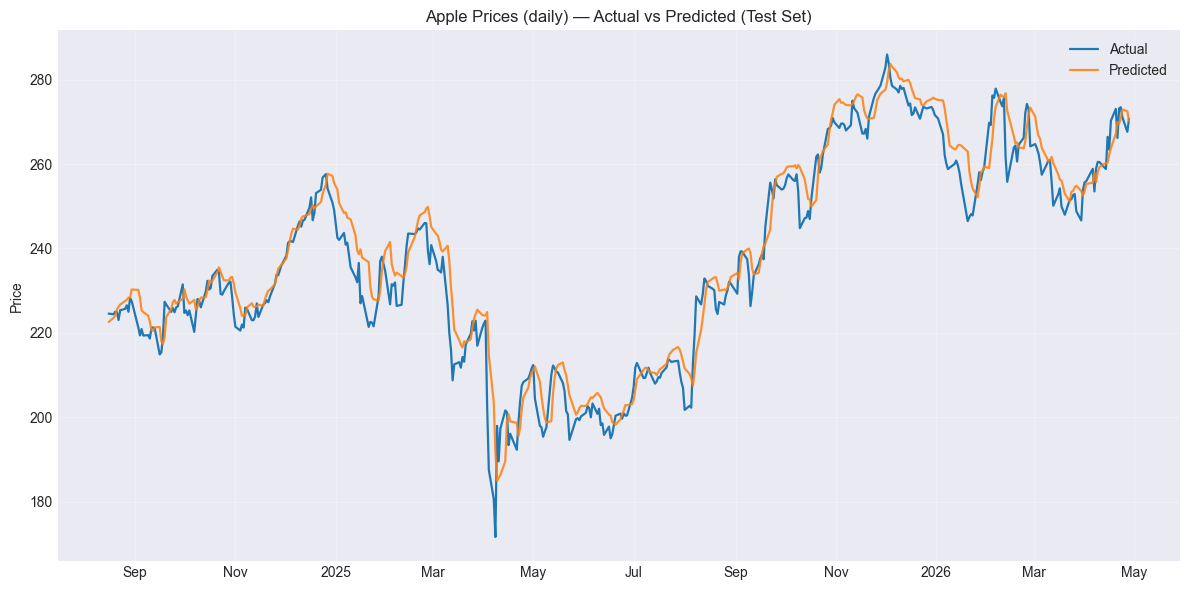

In [14]:
dates_test = datetime_index[-len(predictions):]

#Plot with real dates on the x-axis
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test_unscaled.flatten(), label="Actual", linewidth=1.6)
plt.plot(dates_test, predictions.flatten(), label="Predicted", linewidth=1.6, alpha=0.85)

plt.title("Apple Prices (daily) — Actual vs Predicted (Test Set)")
plt.ylabel("Price")
plt.legend()

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

Checking the Accuracy of my model:

In [15]:
# --- Directional Accuracy ---

# Actual and predicted price changes
actual_direction = np.sign(np.diff(y_test_unscaled))
predicted_direction = np.sign(np.diff(predictions))

# Directional accuracy
directional_accuracy = np.mean(actual_direction == predicted_direction)

print(f"Directional Accuracy: {directional_accuracy * 100:.2f}%") 

Directional Accuracy: 50.00%


In [16]:
# --- MAPE-based Accuracy ---

mape = np.mean(np.abs((y_test_unscaled - predictions) / y_test_unscaled)) * 100
accuracy_mape = 100 - mape

print(f"MAPE: {mape:.2f}%")
print(f"MAPE-based Accuracy: {accuracy_mape:.2f}%")

MAPE: 1.86%
MAPE-based Accuracy: 98.14%


Comparing the LSTMs perfomance agaisnt a baseline

In [17]:
#Persistence prediction (scaled space)
naive_pred_scaled = X_test[:, -1, 0]  #last Close in each window

#Inverse transform
naive_pred = scalers[0].inverse_transform(
    naive_pred_scaled.reshape(-1, 1)
).flatten()

#True values already inverse transformed earlier
#y_test_unscaled exists from your code

#Metrics
naive_rmse = np.sqrt(mean_squared_error(y_test_unscaled, naive_pred))
naive_mae = mean_absolute_error(y_test_unscaled, naive_pred)

print(f"\nNaive Persistence RMSE: ${naive_rmse:.2f}")
print(f"Naive Persistence MAE : ${naive_mae:.2f}")


Naive Persistence RMSE: $3.95
Naive Persistence MAE : $2.69


Predict the close price for tomorrow

In [18]:
#Recreating the full scaled price data - reusing the previous scalers
full_price_scaled = scale_data(price_data, scalers)

#Creating a complete dataset, combining both price data with sentiment data
full_final = np.hstack([full_price_scaled, sentiment_data])

#Extract the last 25 timesteps
last_25_days = full_final[-time_step:]

#Reshape the input so it is suitable to be fed into an LSTM
X_tomorrow = np.reshape(last_25_days, (1, time_step, full_final.shape[1]))

Verification code to check the code is actually using the correct dates (last 25 days) to make a future prediction

In [19]:
#Last 25 dates
last_25_dates = pd.to_datetime(datetime_index[-25:])

#Last 25 raw close prices (unscaled)
last_25_closes = price_data[-25:, 0]           

#Last 25 scaled close values
scaled_closes = last_25_days[:, 0]

#Last 25 sentiments
last_25_sent = sentiment_data[-25:, 0]

verification_table = pd.DataFrame({
    'Date':           last_25_dates.strftime('%Y-%m-%d'),
    'Raw_Close':      last_25_closes,
    'Scaled_Close':   scaled_closes,
    'Sentiment_Score': last_25_sent
})

print(verification_table)

          Date   Raw_Close  Scaled_Close  Sentiment_Score
0   2026-03-24  251.639999      1.466842         0.056148
1   2026-03-25  252.619995      1.473063        -0.047522
2   2026-03-26  252.889999      1.474777         0.098156
3   2026-03-27  248.800003      1.448812        -0.323553
4   2026-03-30  246.630005      1.435036         0.000000
5   2026-03-31  253.789993      1.480491        -0.270221
6   2026-04-01  255.630005      1.492172         0.071230
7   2026-04-02  255.919998      1.494013        -0.145466
8   2026-04-06  258.859985      1.512677         0.160904
9   2026-04-07  253.500000      1.478650         0.096317
10  2026-04-08  258.899994      1.512931         0.101280
11  2026-04-09  260.489990      1.523025        -0.009719
12  2026-04-10  260.480011      1.522962        -0.302388
13  2026-04-13  259.200012      1.514836         0.254051
14  2026-04-14  258.829987      1.512487         0.060146
15  2026-04-15  266.429993      1.560735        -0.006066
16  2026-04-16

In [20]:
#Using the model, predict an output (which is the scaled close)
scaled_prediction = model.predict(X_tomorrow)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


In [21]:
#Inverse the scaling to get the actual predicted price in dollars
predicted_close = scalers[0].inverse_transform(scaled_prediction)

last_date = pd.to_datetime(datetime_index[-1])
next_date = last_date + pd.offsets.BDay(1)
next_date_str = next_date.strftime("%Y-%m-%d") 

print (next_date_str)

print(f"\nPredicted AAPL Close Price for {next_date_str}: ${predicted_close[0][0]:.2f}")

2026-04-29

Predicted AAPL Close Price for 2026-04-29: $271.72


In [22]:
importlib.reload(Common_Functions)

Common_Functions.WriteToDatabase("Insert",str(next_date_str),"LSTM_Close_Price",str(predicted_close[0][0]))
print("Data Sucessfully Saved")

Data Sucessfully Saved
